# 머신러닝 진입 전 실습 문제지
### NumPy · Pandas · matplotlib · seaborn 점검

> **목적**: 함수 암기 점검이 아니라, "ML 직전 단계에서 이 도구로 무슨 판단을 하는가"를 훈련한다.
> **데이터**: Titanic (`train.csv`)
> **구성**: 3개 레벨 × 5문제 = 총 15문제
> **푸는 법**: 각 문제마다 코드를 직접 쳐서 출력을 확인하고, 맨 아래 **사고 과제**에 한 줄로 답한다.

---

## 공통 준비 코드

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")
```

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.magics import display

# LEVEL 1 — 도구 장악
> 함수가 데이터를 **어떻게 바꾸는지** 손으로 확인하는 단계. 출력 모양을 반드시 눈으로 보라.

---

### 문제 1-1. 데이터의 첫인상 잡기

`df`를 불러온 직후, 아래 3가지를 한 번에 파악하라.
1. 전체 행/열 수
2. 각 컬럼의 데이터 타입
3. 컬럼별 결측치 개수

**사고 과제**: `info()` 하나로도 위 3개가 어느 정도 보인다. 그런데 `isnull().sum()`을 굳이 따로 쓰는 이유는 뭘까?

In [30]:
import numpy as np
import pandas as pd

df = pd.read_csv('./../03_data_visualization/data/titanic.csv')

print(df.shape)
print(df.dtypes)
print("-"*50)
print(df.isnull().sum())

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
--------------------------------------------------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### 문제 1-2. NumPy 브로드캐스팅으로 요금 일괄 조정

`Fare` 컬럼을 NumPy 배열로 꺼낸 뒤, 모든 요금에 1.1을 곱해(10% 인상) 새 배열을 만들어라. **for문을 쓰지 말 것.**

```python
fare_arr = df["Fare"].values   # 여기서 시작
```

**사고 과제**: `df["Fare"] * 1.1` 로 해도 결과는 같다. 그런데 이 연산이 내부적으로 빠른 이유를 "브로드캐스팅"과 "벡터화" 두 단어로 설명해보라.


In [36]:
fare_arr = df['Fare'].values
fare = np.array(fare_arr)
fare * 1.1

array([  7.975  ,  78.41163,   8.7175 ,  58.41   ,   8.855  ,   9.30413,
        57.04875,  23.1825 ,  12.24663,  33.07788,  18.37   ,  29.205  ,
         8.855  ,  34.4025 ,   8.63962,  17.6    ,  32.0375 ,  14.3    ,
        19.8    ,   7.9475 ,  28.6    ,  14.3    ,   8.83212,  39.05   ,
        23.1825 ,  34.52625,   7.9475 , 289.3    ,   8.66712,   8.68538,
        30.49288, 161.17288,   8.525  ,  11.55   ,  90.38788,  57.2    ,
         7.95212,   8.855  ,  19.8    ,  12.36587,  10.4225 ,  23.1    ,
         8.68538,  45.73712,   8.66712,   8.855  ,  17.05   ,   8.525  ,
        23.84712,  19.58   ,  43.65625,   8.58   ,  84.40212,  28.6    ,
        68.17712,  39.05   ,  11.55   ,   7.95212,  30.525  ,  51.59   ,
         7.95212,  88.     ,  91.8225 ,  30.69   ,  30.49288,  16.77038,
        11.55   ,   8.97413,   8.7175 ,   9.52875,  11.55   ,  51.59   ,
        80.85   ,  15.89962,  62.14538,   8.415  ,   8.68538,   8.855  ,
        31.9    ,  13.7225 ,   9.9    ,  10.45   , 

### 문제 1-3. 조건으로 잘라내기 (불리언 인덱싱)

다음 두 그룹을 각각 필터링하라.
1. 1등석(`Pclass == 1`) 승객만
2. 1등석이면서 여성(`Sex == "female"`)인 승객만

**사고 과제**: 두 번째 조건에서 `&`를 쓸 때 각 조건을 괄호로 감싸야 한다. 괄호를 빼면 에러가 난다. 왜 그럴까?

In [47]:
first_class = df['Pclass'] == 1
first_class_female = df[(df['Pclass'] == 1) & (df['Sex'] == "female")]
first_class_female

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
...,...,...,...,...,...,...,...,...,...,...,...,...
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
862,863,1,1,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48.0,0,0,17466,25.9292,D17,S
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C


### 문제 1-4. loc vs iloc 구분하기

아래 3개를 각각 출력하라.
1. 인덱스 5번 승객의 `Name`과 `Age` (라벨 기준)
2. 위에서부터 10번째 행 전체 (위치 기준)
3. `Survived`가 1인 행들의 `Name`만

**사고 과제**: `loc`와 `iloc`이 똑같이 `[5]`를 받아도 다른 결과가 나올 수 있는 상황을 하나 만들어보라. (힌트: 정렬을 한 뒤에)

In [70]:
# df.loc[5][["Name", "Age"]]
# df.loc[:10]
survived = df['Survived'] == 1
# survived
df.iloc[survived]
df.loc[:,"Survived"]

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

### 문제 1-5. 새 컬럼 만들기 (파생 변수)

`SibSp`(형제/배우자)와 `Parch`(부모/자녀)를 더해 `FamilySize`라는 새 컬럼을 만들어라. 그리고 가족이 0명인 사람(혼자 탑승)은 `IsAlone = 1`, 아니면 `0`인 컬럼도 추가하라.

**사고 과제**: 원본에 `SibSp`, `Parch`가 이미 있는데 굳이 `FamilySize`를 새로 만드는 게 ML 관점에서 어떤 이득이 있을까?

In [96]:
familySize = df["SibSp"] + df["Parch"] +1
# familySize

df["familySize"] = familySize
# df["familySize"]

df["IsAlone"] = (df["familySize"] == 1).astype(int)
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,familySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,1


# LEVEL 2 — 진단 사고
> EDA 단계. 데이터가 **뭘 숨기고 있는지** 찾아내는 눈을 기른다. 시각화는 장식이 아니라 진단 도구다.

### 문제 2-1. 결측치 전략 세우기

`Age`, `Cabin`, `Embarked` 세 컬럼의 결측치 비율(%)을 각각 계산하라. 그리고 각 컬럼을 **삭제할지 / 채울지 / 통째로 버릴지** 판단하고 그 이유를 적어라.

**사고 과제**: 결측치 비율이 같아도 처리 전략이 달라질 수 있다. 비율 외에 무엇을 더 봐야 결정할 수 있나?

In [100]:
df[["Age", "Cabin", "Embarked"]].isnull().mean()*100

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64

### 문제 2-2. 생존율을 그룹별로 비교

`Sex`별, `Pclass`별 생존율(`Survived`의 평균)을 각각 구하라. `groupby` 사용.

**사고 과제**: 여기서 `Survived`의 "평균"이 곧 "생존율"이 되는 이유는 뭘까? (힌트: `Survived`가 0과 1로만 되어 있다는 점)

In [121]:
# df[["Sex", "Pclass", "Survived"]]

print(df.groupby("Sex")["Survived"].mean())
print(df.groupby("Pclass")["Survived"].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


### 문제 2-3. 분포를 눈으로 보기 (히스토그램)

`Age`의 분포를 히스토그램으로 그려라. 그리고 정규분포에 가까운지, 한쪽으로 치우쳤는지(왜도) 눈으로 판단하라.

**사고 과제**: `Age`의 결측치를 "평균값으로 채운다"는 전략이 이 분포 모양에서 위험할 수 있는 이유는?

(array([40., 14., 15., 31., 79., 98., 85., 84., 73., 45., 35., 35., 29.,
        16., 13., 11.,  4.,  5.,  1.,  1.]),
 array([ 0.42 ,  4.399,  8.378, 12.357, 16.336, 20.315, 24.294, 28.273,
        32.252, 36.231, 40.21 , 44.189, 48.168, 52.147, 56.126, 60.105,
        64.084, 68.063, 72.042, 76.021, 80.   ]),
 <BarContainer object of 20 artists>)

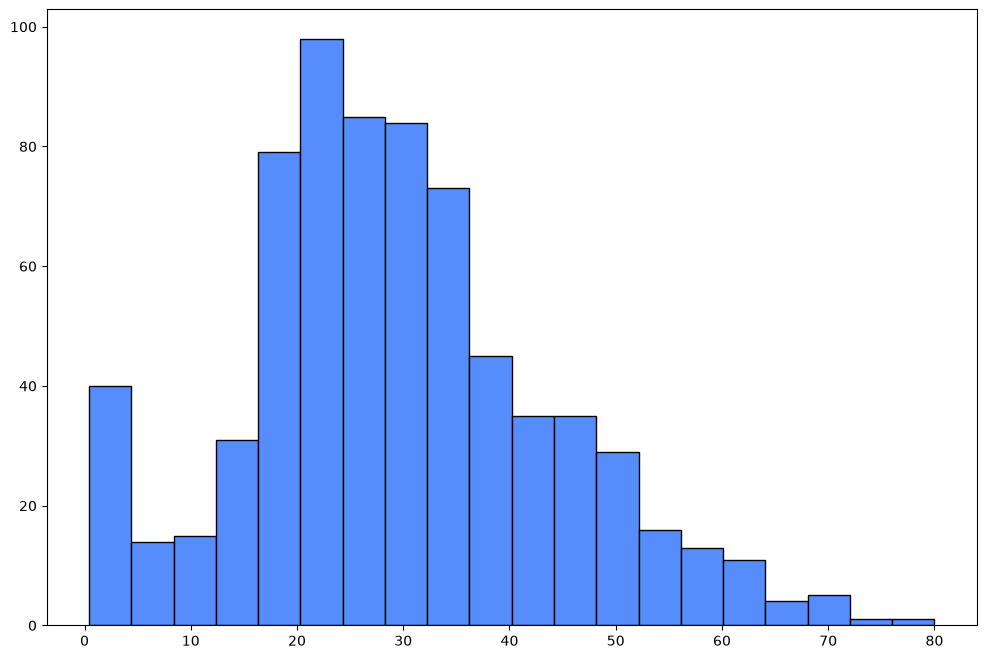

In [129]:
age = df["Age"]
# age

plt.figure(figsize=(12,8))
plt.hist(age, bins=20, edgecolor="black")

### 문제 2-4. 변수 간 관계 보기 (seaborn)

seaborn으로 `Pclass`와 `Survived`의 관계를 막대그래프(`barplot`)로 그려라. 그리고 `Age`와 `Fare`의 관계를 산점도(`scatterplot`)로 그려라.

**사고 과제**: 막대그래프와 산점도는 각각 어떤 종류의 변수 관계를 볼 때 쓰는가? (범주형 vs 연속형 관점에서)

<Axes: xlabel='Pclass', ylabel='Survived'>

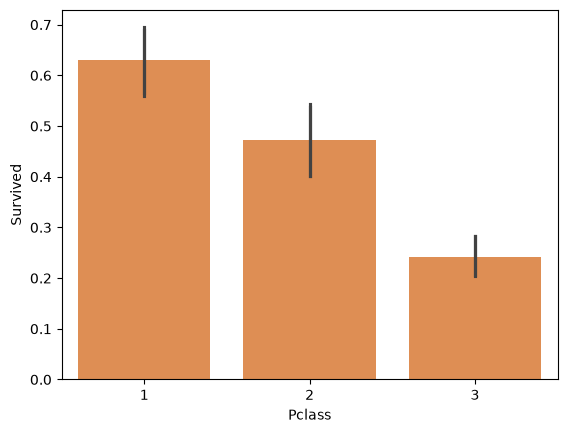

In [133]:
sns.barplot(x=df["Pclass"], y=df["Survived"])
sns.barplot(data=df, x="Pclass", y="Survived")

<Axes: xlabel='Age', ylabel='Fare'>

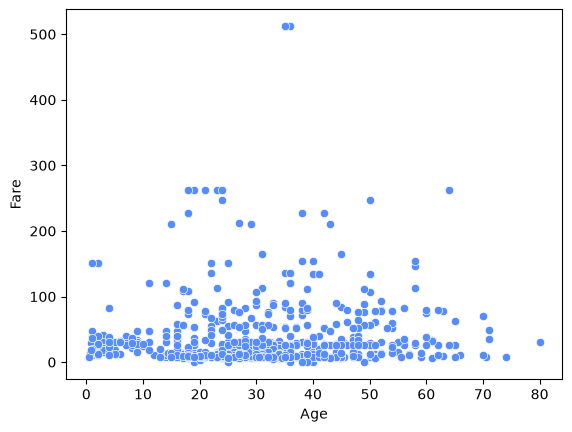

In [137]:
sns.scatterplot(x=df["Age"], y= df["Fare"])

### 문제 2-5. 상관관계 히트맵

숫자형 컬럼들 간의 상관계수를 구하고, seaborn `heatmap`으로 시각화하라. `Survived`와 가장 강한 상관을 가진 변수를 찾아라.

**사고 과제**: 상관계수가 높다고 해서 "그 변수가 생존의 원인"이라고 말할 수 없다. 왜? (공분산·상관 개념과 연결해서)

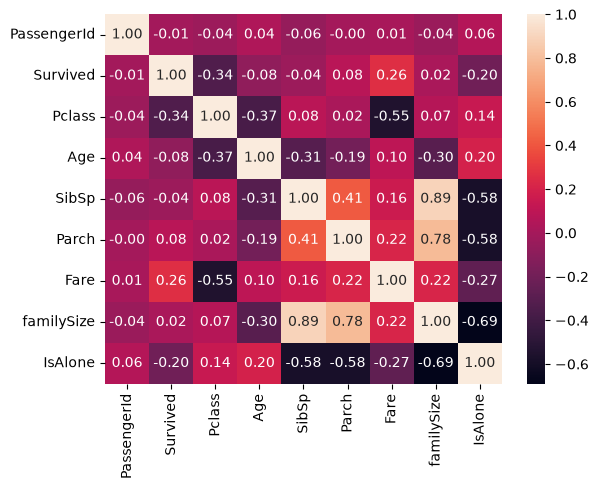

In [150]:
# display(df)
space = df.select_dtypes(include="number")
corr = space.corr()

sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()

# LEVEL 3 — ML 진입 사고
> "이 데이터를 모델에 넣으려면 무엇을 해야 하나"를 판단하는 단계. 정답을 외우는 게 아니라 **결정하는** 문제다.

### 문제 3-1. 문자를 숫자로 (인코딩)

`Sex` 컬럼(`male`/`female`)을 숫자(0/1)로 변환하라. 그리고 `Embarked`(`C`/`Q`/`S`)도 숫자로 변환하라.

**사고 과제**: `Sex`는 `map`으로 0/1로 바꾸면 되는데, `Embarked`를 단순히 0/1/2로 바꾸면 ML 모델이 오해할 수 있다. 왜일까? (힌트: 모델은 숫자의 크기를 의미로 받아들인다 → 원핫 인코딩)

In [154]:
df["Sex"]=df["Sex"].map({"male":0, "female":1})
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,familySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",NaN,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",NaN,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",NaN,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",NaN,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",NaN,35.0,0,0,373450,8.0500,NaN,S,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",NaN,27.0,0,0,211536,13.0000,NaN,S,1,1
887,888,1,1,"Graham, Miss. Margaret Edith",NaN,19.0,0,0,112053,30.0000,B42,S,1,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,0
889,890,1,1,"Behr, Mr. Karl Howell",NaN,26.0,0,0,111369,30.0000,C148,C,1,1


### 문제 3-2. 나이를 구간으로 (pd.cut)

`Age`를 `0~10, 10~20, 20~30, 30~40, 40~50, 50~` 구간으로 나눠 `AgeGroup` 컬럼을 만들고, 구간별 생존율을 구하라.

**사고 과제**: 연속값인 `Age`를 굳이 구간으로 쪼개는 게 어떤 경우에 모델 성능에 도움이 되고, 어떤 경우에 정보 손실이 될까?

In [161]:
bins = [0,10,20,30,40,50,100]
labels = ["0-10","10-20","20-30","30-40","40-50","50+"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)
df.groupby("AgeGroup")["Survived"].mean()

AgeGroup
0-10     0.593750
10-20    0.382609
20-30    0.365217
30-40    0.445161
40-50    0.383721
50+      0.343750
Name: Survived, dtype: float64

### 문제 3-3. 스케일 차이 확인

`Age`(0~80 범위)와 `Fare`(0~500 범위)의 값 범위를 비교하라. 두 컬럼의 min/max/평균을 출력해서 스케일 차이를 확인하라.

**사고 과제**: 두 변수의 스케일이 크게 다르면 일부 ML 모델에서 문제가 된다. 어떤 모델이 스케일에 민감하고, 왜 그런지 생각해보라. (힌트: 거리 기반 모델)

In [169]:
df[["Age", "Fare"]].describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


### 문제 3-4. 모델에 넣을 데이터 추리기

ML 모델에 넣기 위해 다음을 수행하라.
1. 모델이 쓸 수 없는 컬럼(`Name`, `Ticket`, `Cabin`, `PassengerId`)을 제거
2. 결측치를 모두 처리
3. 문자형 컬럼을 모두 숫자로 변환

**사고 과제**: `Name`을 그냥 버렸는데, 사실 이름 안에는 ML에 쓸 수 있는 정보가 숨어 있다. 뭘까? (힌트: Mr, Mrs, Miss...)

In [192]:
# df = df.drop(["Name", "Ticket", "Cabin", "PassengerId"], axis=1)
df.isnull().sum()

# df["Sex"] = df["Sex"].fillna(df["Sex"].median())
# # df["Age"] = df["Age"].fillna(df["Age"].median())
# df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# df

Survived        0
Pclass          0
Sex           891
Age             0
SibSp           0
Parch           0
Fare            0
Embarked        0
familySize      0
IsAlone         0
AgeGroup      177
dtype: int64

### 문제 3-5. Feature와 Target 분리

최종 정제된 데이터에서 **X(피처)**와 **y(타겟)**를 분리하라.
- `y` = `Survived`
- `X` = `Survived`를 제외한 나머지

```python
X = df.drop("Survived", axis=1)
y = df["Survived"]
```

**사고 과제**: 만약 `X`에 실수로 `Survived`를 남겨두면 어떤 일이 벌어질까? 모델 정확도가 100%에 가깝게 나온다면 그건 좋은 걸까? (힌트: 데이터 누수, data leakage)

In [196]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print(X.shape)
print(y.shape)

(891, 10)
(891,)


## 마무리 — 전체를 관통하는 질문

> 이 15문제는 결국 하나의 흐름이다:
> **불러오기(L1) → 진단하기(L2) → 모델에 넣을 형태로 만들기(L3)**
>
> 내일 ML 수업에서 모델 코드를 처음 보면, 그 코드 직전까지 일어나야 하는 모든 일이 바로 이 문제지다.
> 모델은 마지막 한 줄(`model.fit(X, y)`)일 뿐, 진짜 일은 그 앞에서 다 끝난다.

**최종 사고 과제**: 위 15문제 중, ML 성능을 가장 크게 좌우할 것 같은 단계 하나를 고르고 그 이유를 한 문단으로 적어라.
